<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-alexnet/blob/main/symmetric_cross_entropy_alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from keras.models import Model
from keras.layers import Input
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"

In [6]:
train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


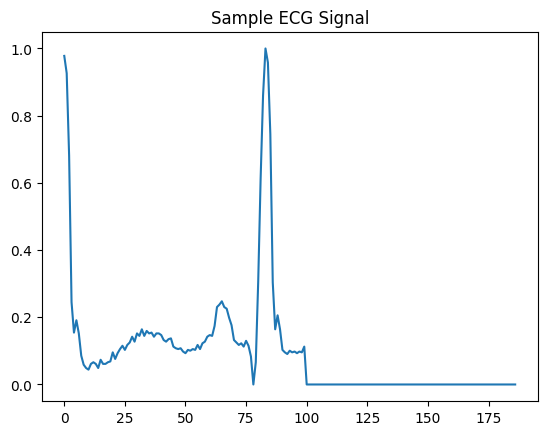

In [7]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

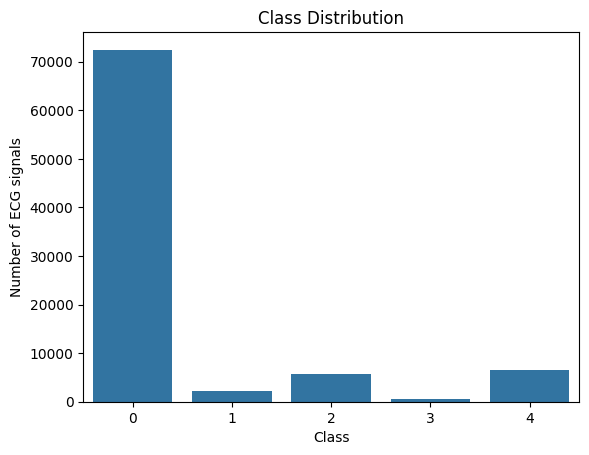

In [8]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [9]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [10]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [11]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [12]:
print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [13]:
X_res = X_res[:120000]
y_res = y_res[:120000]

In [14]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [16]:
X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [17]:
import tensorflow as tf

def symmetric_cross_entropy(alpha=1.0, beta=1.0):

    def loss(y_true, y_pred):

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        y_true = tf.clip_by_value(y_true, 1e-4, 1.0)

        ce = -tf.reduce_sum(
            y_true * tf.math.log(y_pred),
            axis=-1
        )

        rce = -tf.reduce_sum(
            y_pred * tf.math.log(y_true),
            axis=-1
        )

        return alpha * ce + beta * rce

    return loss

In [18]:
def alexnet_ecg():

    inputs = Input(shape=(187, 1))

    x = Conv1D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)

    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Flatten()(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    loss_fn = tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    )

    model.compile(
    optimizer='adam',
    loss=symmetric_cross_entropy(alpha=1.0, beta=1.0),
    metrics=['accuracy']
)
    return model

In [19]:
model = alexnet_ecg()
print("Loss:", model.loss)

Loss: <function symmetric_cross_entropy.<locals>.loss at 0x7f7a004f3ba0>


In [20]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr = to_categorical(y_res[train_idx], 5)
    y_va = to_categorical(y_res[val_idx], 5)

    model = alexnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=10,
        batch_size=128,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)
print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8505 - loss: 2.1321
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9410 - loss: 0.8577
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9577 - loss: 0.6177
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9676 - loss: 0.4828
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9715 - loss: 0.4263
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9761 - loss: 0.3557
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9783 - loss: 0.3226
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9808 - loss: 0.2859
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9839 - loss: 0.2447
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9839 - loss: 0.2456
Fold 1 Accuracy: 0.9846

Fold 2
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8536 - loss: 2.0713
Epoch 2/10

In [21]:
model = alexnet_ecg()
print(model.loss)

<function symmetric_cross_entropy.<locals>.loss at 0x7f7a00659e40>


In [22]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8683 - loss: 1.8753 - val_accuracy: 0.9217 - val_loss: 1.1188
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9450 - loss: 0.8004 - val_accuracy: 0.9505 - val_loss: 0.7304
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9619 - loss: 0.5602 - val_accuracy: 0.9599 - val_loss: 0.5713
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9696 - loss: 0.4493 - val_accuracy: 0.9725 - val_loss: 0.4030
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9754 - loss: 0.3708 - val_accuracy: 0.9802 - val_loss: 0.2909
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9788 - loss: 0.3229 - val_accuracy: 0.9797 - val_loss: 0.2965
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9816 - loss: 0.2815 - val_accuracy: 0.9801 - val_loss: 0.2802
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9830 - loss: 0.2622 - val_accuracy: 

In [23]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
Validation MCC: 0.9714736398658639


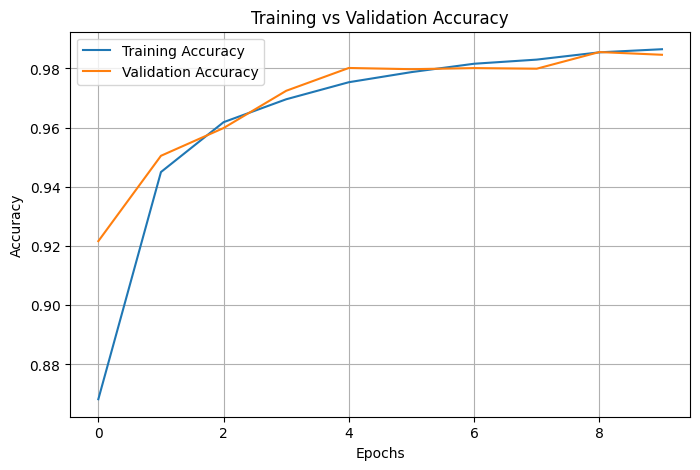

Final Training Accuracy: 0.9865
Final Validation Accuracy: 0.9846


In [24]:
# Cell 24: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

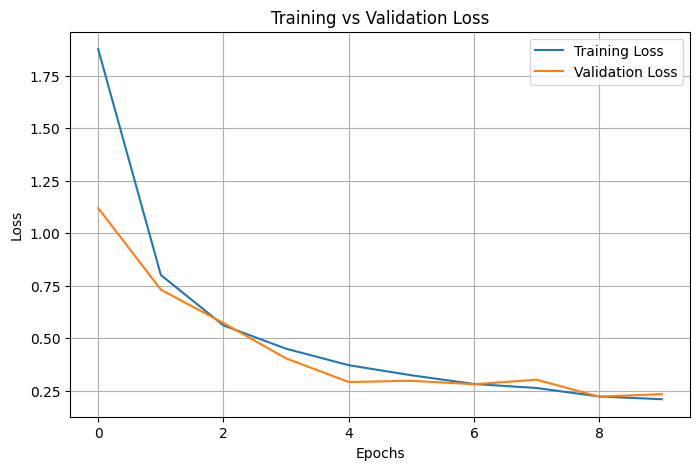

Final Training Loss: 0.2088
Final Validation Loss: 0.2332


In [25]:
# Cell 25: Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3504
Test Accuracy: 0.9778


In [27]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.72      0.86      0.78       556
         2.0       0.94      0.95      0.95      1448
         3.0       0.86      0.59      0.70       162
         4.0       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.88      0.88     21892
weighted avg       0.98      0.98      0.98     21892



In [28]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
num_classes = cm.shape[0]

# Lists
precision = []
recall = []
f1 = []
specificity = []
support = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    prec = TP / (TP + FP) if (TP + FP) != 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) != 0 else 0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0
    f1_score = (2 * prec * rec) / (prec + rec) if (prec + rec) != 0 else 0

    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)
    specificity.append(spec)
    support.append(np.sum(cm[i, :]))

# Convert to numpy
precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)
specificity = np.array(specificity)
support = np.array(support)

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)

# Macro Average
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_spec = np.mean(specificity)

# Weighted Average
weights = support / np.sum(support)

weighted_precision = np.sum(precision * weights)
weighted_recall = np.sum(recall * weights)
weighted_f1 = np.sum(f1 * weights)
weighted_spec = np.sum(specificity * weights)

# Create DataFrame
report_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1-score": f1,
    "specificity": specificity,
    "support": support
})

report_df.index = [f"Class {i}" for i in range(num_classes)]

# Add summary rows
summary_df = pd.DataFrame({
    "precision": [accuracy, macro_precision, weighted_precision],
    "recall":    [accuracy, macro_recall, weighted_recall],
    "f1-score":  [accuracy, macro_f1, weighted_f1],
    "specificity": [np.nan, macro_spec, weighted_spec],
    "support":   [np.sum(support), np.sum(support), np.sum(support)]
}, index=["accuracy", "macro avg", "weighted avg"])

# Combine
final_df = pd.concat([report_df, summary_df])

# Print
print(final_df.round(3))

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision  recall  f1-score  specificity  support
Class 0           0.991   0.986     0.988        0.955    18118
Class 1           0.720   0.863     0.785        0.991      556
Class 2           0.940   0.954     0.947        0.996     1448
Class 3           0.857   0.593     0.701        0.999      162
Class 4           0.985   0.986     0.985        0.999     1608
accuracy          0.978   0.978     0.978          NaN    21892
macro avg         0.899   0.876     0.881        0.988    21892
weighted avg      0.979   0.978     0.978        0.962    21892


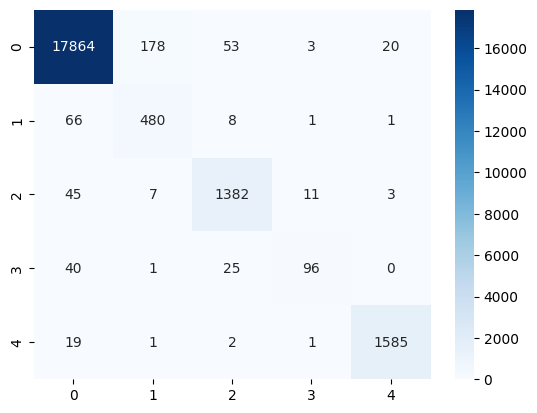

In [29]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()